In [1]:
# Testing out syntax and examples for pymgrit

# Quickstart
from pymgrit import *

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Create Dahlquist’s test problem for the time interval [0, 5]
# with 101 equidistant time points
# (100 time points + 1 time point for the initial time t = 0):
dahlquist = Dahlquist(t_start=0, t_stop=5, nt=101)

In [3]:
# This tells PyMGRIT to set up a hierarchy with
# two temporal grid levels using the test problem dahlquist
# and a temporal coarsening factor of two,
# i.e., on the fine grid, the number of time points is 101,
# and on the coarse grid, 51 (=100/2+1) time points are used.
dahlquist_multilevel_structure = simple_setup_problem(problem=dahlquist, level=2, coarsening=2)


In [4]:
# Set up the MGRIT solver for the test problem using
# dahlquist_multilevel_structure and set the solver tolerance to 1e-10:
mgrit = Mgrit(problem=dahlquist_multilevel_structure, tol=1e-10)


INFO - 13-08-22 21:01:00 - Start setup
INFO - 13-08-22 21:01:00 - Setup took 0.008977413177490234 s


In [5]:
# Finally, solve the test problem using
# the solve() routine of the solver mgrit:
info = mgrit.solve()

INFO - 13-08-22 21:01:48 - Start solve
INFO - 13-08-22 21:01:48 - iter 1  | conv: 7.186185937025429e-05   | conv factor: -                     | runtime: 0.005980968475341797 s 
INFO - 13-08-22 21:01:48 - iter 2  | conv: 1.246106707585954e-06   | conv factor: 0.017340307062827735  | runtime: 0.004984855651855469 s 
INFO - 13-08-22 21:01:48 - iter 3  | conv: 2.1015566149418615e-08  | conv factor: 0.016864981162112075  | runtime: 0.005997657775878906 s 
INFO - 13-08-22 21:01:48 - iter 4  | conv: 3.1441273895579124e-10  | conv factor: 0.014960945459206166  | runtime: 0.006982088088989258 s 
INFO - 13-08-22 21:01:48 - iter 5  | conv: 3.975216519949153e-12   | conv factor: 0.012643306162312011  | runtime: 0.004990816116333008 s 
INFO - 13-08-22 21:01:48 - Solve took 0.0668177604675293 s
INFO - 13-08-22 21:01:48 - Run parameter overview
  time interval             : [0.0, 5.0]
  number of time points     : 101
  max dt                    : 0.05000000000000071
  number of levels          : 2


In [6]:
# Tutorial
# This tutorial demonstrates basic usage of the PyMGRIT package.
# Our goal is solving Dahlquist’s test problem,
# u' = lambda*u in (0,5] with u(0) = 1,
# discretized by Backward Euler. To accomplish this, this tutorial
# will go through the following tasks:
# 1. Writing the vector class holding all time-dependent information
# 2. Writing the application class holding any time-independent data
# 3. Solving the problem
# 4. Looking at results

# Vector Class:
# The first step is to write a data structure that contains
# the solution of a single point in time. The data structure
# must inherit from PyMGRIT’s core Vector class.
import numpy as np
from pymgrit.core.vector import Vector

In [7]:
# Then, we define the class VectorDahlquist containing
# a scalar member variable value:
# Furthermore, we must define the following seven member functions:
# set_values, get_values, clone, clone_zero, clone_rand,
# __add__, __sub__, __mul__, norm, pack and unpack.
class VectorDahlquist(Vector):
    """
    Vector class for Dahlquist's test equation
    """

    def __init__(self, value):
        super().__init__()
        self.value = value

    # The function set_values receives data values and overwrites the
    # values of the vector data and get_values returns the vector data.
    # For our class VectorDahlquist, the vector data is the scalar member
    # variable value:
    def set_values(self, value):
        self.value = value

    def get_values(self):
        return self.value

    # The function clone clones the object.
    # The function clone_zero returns a vector object initialized with zeros;
    # clone_rand similarly returns a vector object initialized with random data.
    # For our class VectorDahlquist, these member functions are defined
    # as follows:
    def clone(self):
        return VectorDahlquist(self.value)

    def clone_zero(self):
        return VectorDahlquist(0)

    def clone_rand(self):
        return VectorDahlquist(np.random.rand(1)[0])
    
    # The functions __add__, __sub__, __mul__, and norm define
    # the addition and subtraction of two vector objects and
    # the norm of a vector object, respectively. For our class
    # VectorDahlquist, adding or subtracting two vector objects
    # means adding or subtracting the values of the member variable
    # value by using the functions get_values and set_values.
    # The multiplication defines the multiplication of a vector objects
    # with a float. We define the norm of a vector object as the norm
    # (from numpy) of the member variable value:
    def __add__(self, other):
        tmp = VectorDahlquist(0)
        tmp.set_values(self.get_values() + other.get_values())
        return tmp

    def __sub__(self, other):
        tmp = VectorDahlquist(0)
        tmp.set_values(self.get_values() - other.get_values())
        return tmp

    def __mul__(self, other):
        tmp = VectorDahlquist(0)
        tmp.set_values(self.get_values() * other)
        return tmp

    def norm(self):
        return np.linalg.norm(self.value)

    # The functions pack and unpack define the data to be communicated
    # and how data is unpacked after receiving it. For our class
    # VectorDahlquist, packing means setting the data to be communicated
    # to the member variable value and unpacking means setting the member
    # variable value to the received scalar value:
    def pack(self):
        return self.value

    def unpack(self, value):
        self.value = value


In [8]:
# Application Class:
# In the next step we write the application class that contains information
# about the problem we want to solve. Every application class must inherit
# from PyMGRIT’s core Application class.
# For our test problem, we import PyMGRIT’s core Application class:
from pymgrit.core.application import Application

In [9]:
# Then, we define the class Dahlquist containing the member variable
# vector_template that defines the data structure for any user-defined
# time point as well as the member variable vector_t_start that holds
# the initial condition at time t_start:
# Note: The time interval of the problem is defined in the superclass
# Application. This PyMGRIT core class contains the following
# member variables:
# t_start : start time (left bound of time interval)
# t_end : end time (right bound of time interval)
# nt : number of time points
class Dahlquist(Application):
    """
    Application class for Dahlquist's test equation,
        u' = lambda * u, u(0) = 1,
    with lambda = -1
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Set the data structure for any user-defined time point
        self.vector_templace = VectorDahlquist(0)

        # Set the initial condition
        self.vector_t_start = VectorDahlquist(1)

        # Furthermore, we must define the time integration routine as
        # the member function step that evolves a vector u_start from
        # time t_start to time t_stop. For our test problem, we take
        # a backward Euler step:
        def step(self, u_start: VectorDahlquist, t_start: float, t_stop: float) -> VectorDahlquist:
            z = (t_stop - t_start) * -1 # Note: lambda = -1
            tmp = 1 / (1 - z) * u_start.get_values()
            return VectorDahlquist(tmp)



In [10]:
# Solving the problem:
# The third step is to set up an MGRIT solver for the test problem.
# First, import PyMGRIT:
from pymgrit import *

In [11]:
# Create Dahlquist's test problem with 101 time steps in the interval [0, 5]
dahlquist = Dahlquist(t_start=0, t_stop=5, nt=101)


In [12]:
# Construct a two-level multigrid hierarchy for the test problem using a coarsening factor of 2
dahlquist_multilevel_structure = simple_setup_problem(problem=dahlquist, level=2, coarsening=2)


In [13]:
# Set up the MGRIT solver for the test problem and set the solver tolerance to 1e-10
mgrit = Mgrit(problem=dahlquist_multilevel_structure, tol=1e-10)


INFO - 13-08-22 21:32:20 - Start setup
INFO - 13-08-22 21:32:20 - Setup took 0.01696944236755371 s


In [14]:
# Solve the test problem
info = mgrit.solve()

INFO - 13-08-22 21:32:24 - Start solve
INFO - 13-08-22 21:32:24 - iter 1  | conv: 7.186185937025429e-05   | conv factor: -                     | runtime: 0.006980419158935547 s 
INFO - 13-08-22 21:32:24 - iter 2  | conv: 1.246106707585954e-06   | conv factor: 0.017340307062827735  | runtime: 0.0050182342529296875 s
INFO - 13-08-22 21:32:24 - iter 3  | conv: 2.1015566149418615e-08  | conv factor: 0.016864981162112075  | runtime: 0.00598454475402832 s  
INFO - 13-08-22 21:32:24 - iter 4  | conv: 3.1441273895579124e-10  | conv factor: 0.014960945459206166  | runtime: 0.0029888153076171875 s
INFO - 13-08-22 21:32:24 - iter 5  | conv: 3.975216519949153e-12   | conv factor: 0.012643306162312011  | runtime: 0.003979682922363281 s 
INFO - 13-08-22 21:32:24 - Solve took 0.05484604835510254 s
INFO - 13-08-22 21:32:24 - Run parameter overview
  time interval             : [0.0, 5.0]
  number of time points     : 101
  max dt                    : 0.05000000000000071
  number of levels          : 2

In [15]:
# The last step is to look at the results of our PyMGRIT run.
# In the default setting,
# PyMGRIT’s core routine Mgrit() prints out the setup time.
# The solve() routine
#   prints out the residual history, along with convergence factors and runtimes, and
#   returns the residual history, setup time, and solve time.
# For our example, we can plot the residuals as follows:
# First, we import numpy and pyplot:
import numpy as np
import matplotlib.pyplot as plt

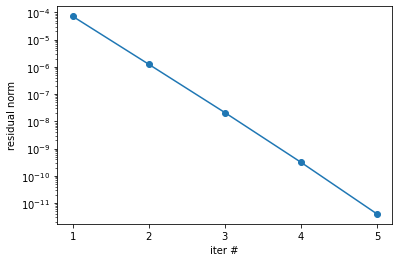

In [17]:
# Then, we get the residuals from the dictionary info:
res = info['conv']

# and plot the residuals:
iters = np.arange(1, res.size+1)
plt.semilogy(iters, res, 'o-')
plt.xticks(iters)
plt.xlabel('iter #')
plt.ylabel('residual norm')
plt.show()


In [18]:
"""
Example: Multigrid hierarchy

There are several ways to create a time-multigrid hierarchy for a problem:

1. Using PyMGRIT’s core function simple_setup_problem()
2. Defining nt evenly spaced numbers over a specified interval
    [t_start, t_stop] for each grid level
3. Specifying time intervals for each grid level
4. Mixing options 2 and 3

Note: Option 1 is only implemented to support an easy start.
We recommend to build the hierarchy manually by using one of the options 2-4.

The following example shows the four different options for creating the same
three-level time-grid hierarchy and builds MGRIT solvers using the resulting
four multilevel objects:
"""

import numpy as np
from pymgrit.dahlquist.dahlquist import Dahlquist
from pymgrit.core.simple_setup_problem import simple_setup_problem
from pymgrit.core.mgrit import Mgrit

In [20]:
# Option 1: Use PyMGRIT's core function simple_setup_problem()
dahlquist_multilevel_structure_1 = simple_setup_problem(problem=Dahlquist(t_start=0, t_stop=5, nt=101), level=3, coarsening=2)
Mgrit(problem=dahlquist_multilevel_structure_1, tol=1e-10).solve()

INFO - 14-08-22 20:04:12 - Start setup
INFO - 14-08-22 20:04:12 - Setup took 0.0160064697265625 s
INFO - 14-08-22 20:04:12 - Start solve
INFO - 14-08-22 20:04:12 - iter 1  | conv: 0.00019401363972256573  | conv factor: -                     | runtime: 0.011998176574707031 s 
INFO - 14-08-22 20:04:12 - iter 2  | conv: 7.975571640343785e-06   | conv factor: 0.041108303786005135  | runtime: 0.008002996444702148 s 
INFO - 14-08-22 20:04:12 - iter 3  | conv: 2.9933240202063605e-07  | conv factor: 0.03753115331652057   | runtime: 0.011995553970336914 s 
INFO - 14-08-22 20:04:12 - iter 4  | conv: 8.881441953215146e-09   | conv factor: 0.029670833806367737  | runtime: 0.0040018558502197266 s
INFO - 14-08-22 20:04:12 - iter 5  | conv: 1.9391939687035342e-10  | conv factor: 0.021834224430206762  | runtime: 0.003999948501586914 s 
INFO - 14-08-22 20:04:12 - iter 6  | conv: 3.0368067573802767e-12  | conv factor: 0.015660149558997243  | runtime: 0.003999233245849609 s 
INFO - 14-08-22 20:04:12 - So

{'conv': array([1.94013640e-04, 7.97557164e-06, 2.99332402e-07, 8.88144195e-09,
        1.93919397e-10, 3.03680676e-12]),
 'time_setup': 0.0160064697265625,
 'time_solve': 0.06399989128112793}

In [21]:
# Build each level using t_start, t_end, and nt
dahlquist_lvl_0 = Dahlquist(t_start=0, t_stop=5, nt=101)
dahlquist_lvl_1 = Dahlquist(t_start=0, t_stop=5, nt=51)
dahlquist_lvl_2 = Dahlquist(t_start=0, t_stop=5, nt=26)
dahlquist_multilevel_structure_2 = [dahlquist_lvl_0, dahlquist_lvl_1, dahlquist_lvl_2]
Mgrit(problem=dahlquist_multilevel_structure_2, tol=1e-10).solve()

INFO - 14-08-22 20:07:15 - Start setup
INFO - 14-08-22 20:07:15 - Setup took 0.01200103759765625 s
INFO - 14-08-22 20:07:15 - Start solve
INFO - 14-08-22 20:07:15 - iter 1  | conv: 0.00019401363972256573  | conv factor: -                     | runtime: 0.008000373840332031 s 
INFO - 14-08-22 20:07:15 - iter 2  | conv: 7.975571640343785e-06   | conv factor: 0.041108303786005135  | runtime: 0.0040013790130615234 s
INFO - 14-08-22 20:07:15 - iter 3  | conv: 2.9933240202063605e-07  | conv factor: 0.03753115331652057   | runtime: 0.007999420166015625 s 
INFO - 14-08-22 20:07:15 - iter 4  | conv: 8.881441953215146e-09   | conv factor: 0.029670833806367737  | runtime: 0.008000850677490234 s 
INFO - 14-08-22 20:07:15 - iter 5  | conv: 1.9391939687035342e-10  | conv factor: 0.021834224430206762  | runtime: 0.004000663757324219 s 
INFO - 14-08-22 20:07:15 - iter 6  | conv: 3.0368067573802767e-12  | conv factor: 0.015660149558997243  | runtime: 0.012027740478515625 s 
INFO - 14-08-22 20:07:15 - S

{'conv': array([1.94013640e-04, 7.97557164e-06, 2.99332402e-07, 8.88144195e-09,
        1.93919397e-10, 3.03680676e-12]),
 'time_setup': 0.01200103759765625,
 'time_solve': 0.06002616882324219}

In [22]:
# Option 3: Specify time intervals for each grid level
t_interval = np.linspace(0, 5, 101)
dahlquist_lvl_0 = Dahlquist(t_interval=t_interval)
dahlquist_lvl_1 = Dahlquist(t_interval=t_interval[::2]) # Takes every second point from t_interval
dahlquist_lvl_2 = Dahlquist(t_interval=t_interval[::4]) # takes every fourth point from t_interval
dahlquist_multilevel_structure_3 = [dahlquist_lvl_0, dahlquist_lvl_1, dahlquist_lvl_2]
Mgrit(problem=dahlquist_multilevel_structure_3, tol=1e-10).solve()

INFO - 14-08-22 20:10:17 - Start setup
INFO - 14-08-22 20:10:17 - Setup took 0.007966279983520508 s
INFO - 14-08-22 20:10:17 - Start solve
INFO - 14-08-22 20:10:17 - iter 1  | conv: 0.00019401363972256573  | conv factor: -                     | runtime: 0.00799250602722168 s  
INFO - 14-08-22 20:10:17 - iter 2  | conv: 7.975571640343785e-06   | conv factor: 0.041108303786005135  | runtime: 0.004001617431640625 s 
INFO - 14-08-22 20:10:17 - iter 3  | conv: 2.9933240202063605e-07  | conv factor: 0.03753115331652057   | runtime: 0.00397038459777832 s  
INFO - 14-08-22 20:10:17 - iter 4  | conv: 8.881441953215146e-09   | conv factor: 0.029670833806367737  | runtime: 0.008002042770385742 s 
INFO - 14-08-22 20:10:17 - iter 5  | conv: 1.9391939687035342e-10  | conv factor: 0.021834224430206762  | runtime: 0.003995418548583984 s 
INFO - 14-08-22 20:10:17 - iter 6  | conv: 3.0368067573802767e-12  | conv factor: 0.015660149558997243  | runtime: 0.007998228073120117 s 
INFO - 14-08-22 20:10:17 - 

{'conv': array([1.94013640e-04, 7.97557164e-06, 2.99332402e-07, 8.88144195e-09,
        1.93919397e-10, 3.03680676e-12]),
 'time_setup': 0.007966279983520508,
 'time_solve': 0.05998969078063965}

In [23]:
# Option 4: Mix options 2 and 3
dahlquist_lvl_0 = Dahlquist(t_start=0, t_stop=5, nt=101)
dahlquist_lvl_1 = Dahlquist(t_interval=dahlquist_lvl_0.t[::2]) # using t from the upper level
dahlquist_lvl_2 = Dahlquist(t_start=0, t_stop=5, nt=26)
dahlquist_multilevel_structure_4 = [dahlquist_lvl_0, dahlquist_lvl_1, dahlquist_lvl_2]
Mgrit(problem=dahlquist_multilevel_structure_4, tol=1e-10).solve()

INFO - 14-08-22 20:15:14 - Start setup
INFO - 14-08-22 20:15:14 - Setup took 0.01199960708618164 s
INFO - 14-08-22 20:15:14 - Start solve
INFO - 14-08-22 20:15:14 - iter 1  | conv: 0.00019401363972256573  | conv factor: -                     | runtime: 0.00800466537475586 s  
INFO - 14-08-22 20:15:14 - iter 2  | conv: 7.975571640343785e-06   | conv factor: 0.041108303786005135  | runtime: 0.004000186920166016 s 
INFO - 14-08-22 20:15:14 - iter 3  | conv: 2.9933240202063605e-07  | conv factor: 0.03753115331652057   | runtime: 0.008004188537597656 s 
INFO - 14-08-22 20:15:14 - iter 4  | conv: 8.881441953215146e-09   | conv factor: 0.029670833806367737  | runtime: 0.00400090217590332 s  
INFO - 14-08-22 20:15:14 - iter 5  | conv: 1.9391939687035342e-10  | conv factor: 0.021834224430206762  | runtime: 0.0040264129638671875 s
INFO - 14-08-22 20:15:14 - iter 6  | conv: 3.0368067573802767e-12  | conv factor: 0.015660149558997243  | runtime: 0.00800013542175293 s  
INFO - 14-08-22 20:15:14 - S

{'conv': array([1.94013640e-04, 7.97557164e-06, 2.99332402e-07, 8.88144195e-09,
        1.93919397e-10, 3.03680676e-12]),
 'time_setup': 0.01199960708618164,
 'time_solve': 0.06000113487243652}

In [25]:
# Example: Solver Parameters

# The MGRIT algorithm in PyMGRIT has a variety of parameters and features.
# This example describes the parameters of PyMGRIT’s core routine Mgrit().

from mpi4py import MPI

from pymgrit.dahlquist.dahlquist import Dahlquist
from pymgrit.core.simple_setup_problem import simple_setup_problem
from pymgrit.core.mgrit import Mgrit

# Create Dahlquist's test problem with 101 time steps in the interval [0, 5]
dahlquist = Dahlquist(t_start=0, t_stop=5, nt=101)

# Construct a two-level multigrid hierarchy for the test problem using a coarsening factor of 2
dahlquist_multilevel_structure = simple_setup_problem(problem=dahlquist, level=2, coarsening=2)

In [27]:
# Set up the MGRIT solver for the test problem
mgrit = Mgrit(problem=dahlquist_multilevel_structure,       # Problem structure
              transfer=None,                                # Spatial grid transfer. Automatically set if None.
              max_iter=10,                                  # Maximum number of iterations (default: 100)
              tol=1e-10,                                    # Stopping tolerance (default: 1e-7)
              nested_iteration=True,                        # Use (True) or do not use (False) nested iterations
                                                            # (default: True)
              cf_iter=1,                                    # Number of CF relaxations (default: 1)
              cycle_type='V',                               # multigrid cycling type (default: 'V'):
                                                            # 'V' -> V-cycles
                                                            # 'F' -> F-cycles
              comm_time=MPI.COMM_WORLD,                     # Time communicator (default: MPI.COMM_WORLD)
              comm_space=MPI.COMM_NULL,                     # Space communicator (default: MPI.COMM_NULL)
              weight_c=1,                                      # C - relaxation weight (default: 1)
              logging_lvl=20,                               # Logging level (default: 20):
                                                            # 10: Debug -> Runtime of all components
                                                            # 20: Info  -> Info per iteration + summary
                                                            # 30: None  -> No information
              output_fcn=None,                              # Function for saving solution values to file
                                                            # (default: None)
              output_lvl=1,                                 # Output level (default: 1):
                                                            # 0 -> output_fcn is never called
                                                            # 1 -> output_fcn is called at the end of the simulation
                                                            # 2 -> output_fcn is called after each MGRIT iteration
              t_norm=2,                                     # Temporal norm
                                                            # 1 -> One-norm
                                                            # 2 -> Two-norm
                                                            # 3 -> Infinity-norm
              random_init_guess=False                       # Use (True) or do not use (False) random initial guess
                                                            # for all unknowns (default: False)
              )

# Solve the test problem
mgrit.solve()

INFO - 14-08-22 20:21:39 - Start setup
INFO - 14-08-22 20:21:39 - Setup took 0.020004749298095703 s
INFO - 14-08-22 20:21:39 - Start solve
INFO - 14-08-22 20:21:39 - iter 1  | conv: 7.186185937025429e-05   | conv factor: -                     | runtime: 0.012038946151733398 s 
INFO - 14-08-22 20:21:39 - iter 2  | conv: 1.246106707585954e-06   | conv factor: 0.017340307062827735  | runtime: 0.011996269226074219 s 
INFO - 14-08-22 20:21:39 - iter 3  | conv: 2.1015566149418615e-08  | conv factor: 0.016864981162112075  | runtime: 0.00800466537475586 s  
INFO - 14-08-22 20:21:39 - iter 4  | conv: 3.1441273895579124e-10  | conv factor: 0.014960945459206166  | runtime: 0.008008480072021484 s 
INFO - 14-08-22 20:21:39 - iter 5  | conv: 3.975216519949153e-12   | conv factor: 0.012643306162312011  | runtime: 0.007991790771484375 s 
INFO - 14-08-22 20:21:39 - Solve took 0.09600305557250977 s
INFO - 14-08-22 20:21:39 - Run parameter overview
  time interval             : [0.0, 5.0]
  number of tim

{'conv': array([7.18618594e-05, 1.24610671e-06, 2.10155661e-08, 3.14412739e-10,
        3.97521652e-12]),
 'time_setup': 0.020004749298095703,
 'time_solve': 0.09600305557250977}

In [ ]:
"""
Example: Output Function

In this example, we show how to save and plot the MGRIT approximation of
the solution of Dahlquist’s test problem. An output function is defined
that saves the solution (here, a single solution value at each time point
is written to an output file via the numpy function save()). This output
function is passed to the MGRIT solver. Depending on the solver setting
(see output_lvl in Solver parameters), the output function:
    is never called,
    is called at the end of the simulation (example_output_fcn_serial.py), or
    is called after each iteration (example_output_fcn.py).
"""

In [28]:
"""
Save and plot the final MGRIT approximation of the solution
Note: This example assumes a sequential run of the simulation.
"""

import pathlib
import numpy as np
import matplotlib.pyplot as plt

from pymgrit.dahlquist.dahlquist import Dahlquist
from pymgrit.core.simple_setup_problem import simple_setup_problem
from pymgrit.core.mgrit import Mgrit

In [29]:
# Define output function that writes the solution to a file
def output_fcn(self):
    # Set path to solution
    path = 'results/' + 'dahlquist'
    # Create path if not existing
    pathlib.Path(path).mkdir(parents=True, exist_ok=True)

    # Save solution to file; here, we just have a single solution value at each time point.
    # Useful member variables of MGRIT solver:
    #   - self.t[0]           : local fine-grid (level 0) time interval
    #   - self.index_local[0] : indices of local fine-grid (level 0) time interval
    #   - self.u[0]           : fine-grid (level 0) solution values
    np.save(path + '/dahlquist',
            [self.u[0][i].get_values() for i in self.index_local[0]])  # Solution values at local time points


In [36]:
# Create Dahlquist's test problem with 101 time steps in the interval [0, 5]
dahlquist = Dahlquist(t_start=0, t_stop=5, nt=101)

# Construct a two-level multigrid hierarchy for the test problem using a coarsening factor of 2
dahlquist_multilevel_structure = simple_setup_problem(problem=dahlquist, level=2, coarsening=2)

# Set up the MGRIT solver for the test problem and set the output function
mgrit = Mgrit(problem=dahlquist_multilevel_structure, output_fcn=output_fcn)

# Solve the test problem
info = mgrit.solve()

for i in mgrit.index_local[0]:
    print(mgrit.u[0][i].get_values())

INFO - 14-08-22 20:36:13 - Start setup
INFO - 14-08-22 20:36:13 - Setup took 0.02000880241394043 s
INFO - 14-08-22 20:36:13 - Start solve
INFO - 14-08-22 20:36:13 - iter 1  | conv: 7.186185937025429e-05   | conv factor: -                     | runtime: 0.012054443359375 s    
INFO - 14-08-22 20:36:13 - iter 2  | conv: 1.246106707585954e-06   | conv factor: 0.017340307062827735  | runtime: 0.016007184982299805 s 
INFO - 14-08-22 20:36:13 - iter 3  | conv: 2.1015566149418615e-08  | conv factor: 0.016864981162112075  | runtime: 0.00799703598022461 s  
INFO - 14-08-22 20:36:13 - Solve took 0.07201743125915527 s
INFO - 14-08-22 20:36:13 - Run parameter overview
  time interval             : [0.0, 5.0]
  number of time points     : 101
  max dt                    : 0.05000000000000071
  number of levels          : 2
  coarsening factors        : [2]
  relaxation weight         : 1.0
  cf_iter                   : 1
  nested iteration          : True
  cycle type                : V
  stopping 

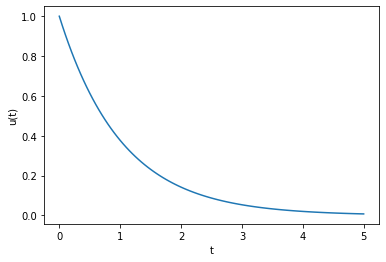

In [37]:
# Plot the solution (Note: modifications necessary if more than one process is used for the simulation!)
t = np.linspace(dahlquist.t_start, dahlquist.t_end, dahlquist.nt)
sol = np.load('results/dahlquist/dahlquist.npy')
plt.plot(t, sol)
plt.xlabel('t')
plt.ylabel('u(t)')
plt.show()

In [44]:
"""
Save and plot the MGRIT approximation of the solution after each iteration

In this example, we show how to use the output function for a parallel run
and save the solution after each iteration.
"""

import pathlib
import os
import numpy as np
import matplotlib.pyplot as plt

from mpi4py import MPI

from pymgrit.brusselator.brusselator import Brusselator
from pymgrit.core.mgrit import Mgrit

In [45]:
# Each process calls the function, so the file of each process must be
# unique. We use the rank to distinguish the files. We save the solution
# and the time point in a list for each local point of one process:
def output_fcn(self):
    # Set path to solution; here, we include the iteration number in the path name
    path = 'results/' + 'brusselator' + '/' + str(self.solve_iter)
    # Create path if not existing
    pathlib.Path(path).mkdir(parents=True, exist_ok=True)

    # Save solution to file.
    # Useful member variables of MGRIT solver:
    #   - self.t[0]           : local fine-grid (level 0) time interval
    #   - self.index_local[0] : indices of local fine-grid (level 0) time interval
    #   - self.u[0]           : fine-grid (level 0) solution values
    #   - self.comm_time_rank : Time communicator rank
    np.save(path + '/brusselator-rank' + str(self.comm_time_rank),
            [[[self.t[0][i], self.u[0][i]] for i in self.index_local[0]]])  # Solution and time at local time points


In [46]:
# Then, we solve the problem in the usual way:

# Create two-level time-grid hierarchy for the Brusselator system
brusselator_lvl_0 = Brusselator(t_start=0, t_stop=12, nt=641)
brusselator_lvl_1 = Brusselator(t_interval=brusselator_lvl_0.t[::20])

# Set up the MGRIT solver using the two-level hierarchy and set the output function
mgrit = Mgrit(problem=[brusselator_lvl_0, brusselator_lvl_1], output_fcn=output_fcn, output_lvl=2, cf_iter=0)

# Solve Brusselator system
info = mgrit.solve()


INFO - 14-08-22 21:10:12 - Start setup
INFO - 14-08-22 21:10:12 - Setup took 0.025964021682739258 s
INFO - 14-08-22 21:10:12 - Start solve
INFO - 14-08-22 21:10:12 - iter 1  | conv: 0.22895689965967167     | conv factor: -                     | runtime: 0.10272717475891113 s  
INFO - 14-08-22 21:10:12 - iter 2  | conv: 0.21930080632509397     | conv factor: 0.957825715892682     | runtime: 0.03790092468261719 s  
INFO - 14-08-22 21:10:12 - iter 3  | conv: 0.003149299243229783    | conv factor: 0.014360636862233997  | runtime: 0.04088592529296875 s  
INFO - 14-08-22 21:10:12 - iter 4  | conv: 1.1354826661339264e-05  | conv factor: 0.003605508967034283  | runtime: 0.0439143180847168 s   
INFO - 14-08-22 21:10:12 - iter 5  | conv: 4.8901291378619663e-08  | conv factor: 0.004306652389958362  | runtime: 0.03594350814819336 s  
INFO - 14-08-22 21:10:12 - Solve took 0.34407949447631836 s
INFO - 14-08-22 21:10:12 - Run parameter overview
  time interval             : [0.0, 12.0]
  number of ti

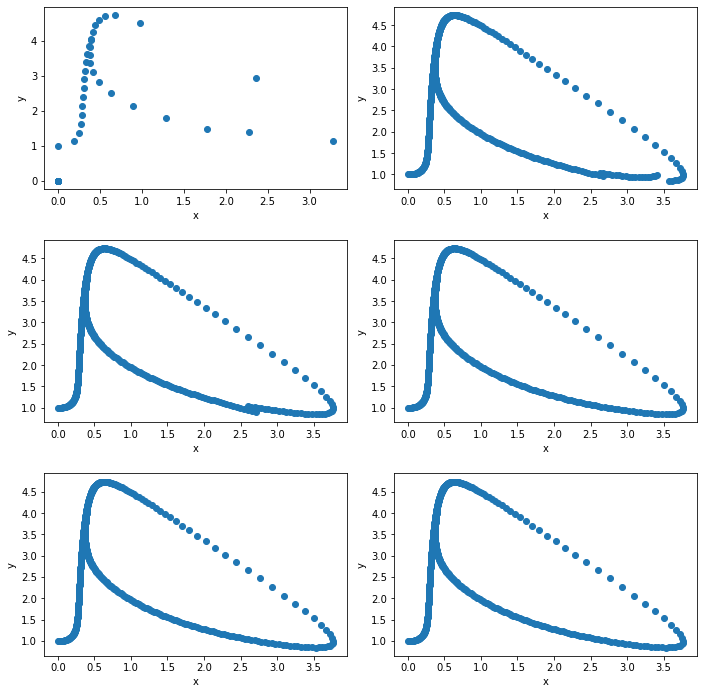

In [47]:
# The last step is to plot the solution for each iteration.
# Therefore, all files have to be loaded and the solution has to be
# assembled in the correct order. To determine the correct order,
# we use the corresponding time points:

# Plot the MGRIT approximation of the solution after each iteration
if MPI.COMM_WORLD.Get_rank() == 0:
    # Dynamic images
    iterations_needed = len(info['conv']) + 1
    cols = 2
    rows = iterations_needed // cols + iterations_needed % cols
    position = range(1, iterations_needed + 1)
    fig = plt.figure(1, figsize=[10, 10])
    for i in range(iterations_needed):
        # Load each file and add the loaded values to sol
        sol = []
        path = 'results/brusselator/' + str(i)
        for filename in os.listdir(path):
            data = np.load(path + '/' + filename, allow_pickle=True).tolist()[0]
            sol += data
        # Sort the solution list by the time
        sol.sort(key=lambda tup: tup[0])
        # Get the solution values
        values = np.array([i[1].get_values() for i in sol])
        ax = fig.add_subplot(rows, cols, position[i])
        # Plot the two solution values at each time point
        ax.scatter(values[:, 0], values[:, 1])
        ax.set(xlabel='x', ylabel='y')
    fig.tight_layout(pad=2.0)
    plt.show()

In [43]:
"""
Time-grid hierarchy with different time integrators

The member function step() of an application class can carry out a
time integration step based on different time integration methods.
The Dahlquist application class implements the following time
integration schemes:
    Backward Euler
    Forward Euler
    Trapezoidal rule
    Implicit mid-point rule
that can be controlled by the member variable method:

def step(self, u_start: VectorDahlquist, t_start: float, t_stop: float) -> VectorDahlquist:

Time integration routine for Dahlquist's test problem:
    BE: Backward Euler
    FE: Forward Euler
    TR: Trapezoidal rule
    MR: implicit Mid-point rule

:param u_start: approximate solution for the input time t_start
:param t_start: time associated with the input approximate solution u_start
:param t_stop: time to evolve the input approximate solution to
:return: approximate solution for the input time t_stop

z = (t_stop - t_start) * -1  # Note: lambda = -1
if self.method == 'BE':
    tmp = 1 / (1 - z) * u_start.get_values()
elif self.method == 'FE':
    tmp = (1 + z) * u_start.get_values()
elif self.method == 'TR':
    tmp = (1 + z / 2) / (1 - z / 2) * u_start.get_values()
elif self.method == 'MR':
    k1 = -1 / (1 - z / 2) * u_start.get_values()
    tmp = u_start.get_values() + (t_stop - t_start) * k1
return VectorDahlquist(tmp)
"""

from pymgrit.dahlquist.dahlquist import Dahlquist
from pymgrit.core.mgrit import Mgrit

# Create Dahlquist's test problem using implicit mid-point rule time integration
dahlquist_lvl0 = Dahlquist(t_start=0, t_stop=5, nt=101, method='MR')
# Create Dahlquist's test problem using backward Euler time integration
dahlquist_lvl1 = Dahlquist(t_start=0, t_stop=5, nt=51, method='BE')

# Setup an MGRIT solver and solve the problem
mgrit = Mgrit(problem=[dahlquist_lvl0, dahlquist_lvl1])
info = mgrit.solve()

INFO - 14-08-22 21:09:45 - Start setup
INFO - 14-08-22 21:09:45 - Setup took 0.008005380630493164 s
INFO - 14-08-22 21:09:45 - Start solve
INFO - 14-08-22 21:09:45 - iter 1  | conv: 0.0003079175789847042   | conv factor: -                     | runtime: 0.003958463668823242 s 
INFO - 14-08-22 21:09:45 - iter 2  | conv: 1.1038989829978764e-05  | conv factor: 0.03585046968210648   | runtime: 0.004016399383544922 s 
INFO - 14-08-22 21:09:45 - iter 3  | conv: 3.8490474036390616e-07  | conv factor: 0.03486775024636893   | runtime: 0.0029900074005126953 s
INFO - 14-08-22 21:09:45 - iter 4  | conv: 1.1905574823105624e-08  | conv factor: 0.030931224208487432  | runtime: 0.003986835479736328 s 
INFO - 14-08-22 21:09:45 - Solve took 0.026899099349975586 s
INFO - 14-08-22 21:09:45 - Run parameter overview
  time interval             : [0.0, 5.0]
  number of time points     : 101
  max dt                    : 0.05000000000000071
  number of levels          : 2
  coarsening factors        : [2]
  r

In [48]:
""" 
In the second example, we use two application classes for implementing
two different time integration methods for the 1D heat equation example:
    Application class 1 implements BDF2.
    Application class 2 implements BDF1.

Note: The vector class used in both application classes contains the
solution at two consecutive time points.

The corresponding example (example_heat_1d_bdf2.py) constructs a
three-level multigrid hierarchy for the 1D heat equation example using
the BDF2 application class on the fine grid (level 0) and the BDF1
application class on the first and second coarse grids (levels 1 and 2):
"""

import numpy as np

from pymgrit.core.mgrit import Mgrit
from pymgrit.heat.heat_1d_2pts_bdf1 import Heat1DBDF1
from pymgrit.heat.heat_1d_2pts_bdf2 import Heat1DBDF2


def rhs(x, t):
    """
    Right-hand side of 1D heat equation example problem at a given space-time point (x,t),
      -sin(pi*x)(sin(t) - a*pi^2*cos(t)),  a = 1

    :param x: spatial grid point
    :param t: time point
    :return: right-hand side of 1D heat equation example problem at point (x,t)
    """
    return - np.sin(np.pi * x) * (np.sin(t) - 1 * np.pi ** 2 * np.cos(t))

def init_cond(x):
    """
    Initial condition of 1D heat equation example,
      u(x,0)  = sin(pi*x)

    :param x: spatial grid point
    :return: initial condition of 1D heat equation example problem
    """
    return np.sin(np.pi * x)

# Time interval
t_start = 0
t_stop = 2
nt = 512  # number of time points excluding t_start
dtau = t_stop / nt  # time-step size

# Time points are grouped in pairs of two consecutive time points
#   => (nt/2) + 1 pairs
# Note: * Each pair is associated with the time value of its first point.
#       * The second value of the last pair (associated with t_stop) is not used.
#       * The spacing within each pair is the same (= dt) on all grid levels.
t_interval = np.linspace(t_start, t_stop, int(nt / 2 + 1))

heat0 = Heat1DBDF2(x_start=0, x_end=1, nx=1001, a=1, dtau=dtau, rhs=rhs, init_cond=init_cond,
                   t_interval=t_interval)
heat1 = Heat1DBDF1(x_start=0, x_end=1, nx=1001, a=1, dtau=dtau, rhs=rhs, init_cond=init_cond,
                   t_interval=heat0.t[::2])
heat2 = Heat1DBDF1(x_start=0, x_end=1, nx=1001, a=1, dtau=dtau, rhs=rhs, init_cond=init_cond,
                   t_interval=heat1.t[::2])

# Setup three-level MGRIT solver and solve the problem
problem = [heat0, heat1, heat2]
mgrit = Mgrit(problem=problem)
info = mgrit.solve()

INFO - 14-08-22 21:12:12 - Start setup
INFO - 14-08-22 21:12:13 - Setup took 0.9883608818054199 s
INFO - 14-08-22 21:12:13 - Start solve
INFO - 14-08-22 21:12:16 - iter 1  | conv: 0.001092756970984564    | conv factor: -                     | runtime: 2.137282371520996 s    
INFO - 14-08-22 21:12:18 - iter 2  | conv: 7.533965512498928e-05   | conv factor: 0.06894456601554226   | runtime: 1.9029417037963867 s   
INFO - 14-08-22 21:12:20 - iter 3  | conv: 5.224003261616423e-06   | conv factor: 0.06933935724751789   | runtime: 1.8570306301116943 s   
INFO - 14-08-22 21:12:22 - iter 4  | conv: 3.6262558966337397e-07  | conv factor: 0.06941526861741842   | runtime: 1.851022720336914 s    
INFO - 14-08-22 21:12:24 - iter 5  | conv: 2.502523006853483e-08   | conv factor: 0.06901120820448937   | runtime: 1.9368157386779785 s   
INFO - 14-08-22 21:12:24 - Solve took 10.910848379135132 s
INFO - 14-08-22 21:12:24 - Run parameter overview
  time interval             : [0.0, 2.0]
  number of time p

In [49]:
import numpy as np

from pymgrit.heat.heat_1d import Heat1D  # 1D Heat equation problem
from pymgrit.heat.heat_1d import VectorHeat1D  # 1D Heat equation vector class
from pymgrit.core.mgrit import Mgrit  # MGRIT solver
from pymgrit.core.grid_transfer import GridTransfer  # Parent grid transfer class
from pymgrit.core.grid_transfer_copy import GridTransferCopy  # Copy transfer class


# Create class for the grid transfer between spatial grids.
# Note: The class must inherit from PyMGRIT's core GridTransfer class.
class GridTransferHeat(GridTransfer):
    """
    Grid Transfer class for the Heat Equation.
    Interpolation: Linear interpolation
    Restriction: Full weighting
    """

    def __init__(self):
        """
        Constructor.
        :rtype: GridTransferHeat object
        """
        super().__init__()

    # Define restriction operator
    def restriction(self, u: VectorHeat1D) -> VectorHeat1D:
        """
        Restrict input vector u using standard full weighting restriction.

        Note: In the 1d heat equation example, we consider homogeneous Dirichlet BCs in space.
              The Heat1D vector class only stores interior points.
        :param u: approximate solution vector
        :return: input solution vector u restricted to a coarse grid
        """
        # Get values at interior points
        sol = u.get_values()

        # Create array for restricted values
        ret_array = np.zeros(int((len(sol) - 1) / 2))

        # Full weighting restriction
        for i in range(len(ret_array)):
            ret_array[i] = sol[2 * i] * 1 / 4 + sol[2 * i + 1] * 1 / 2 + sol[2 * i + 2] * 1 / 4

        # Create and return a VectorHeat1D object with the restricted values
        ret = VectorHeat1D(len(ret_array))
        ret.set_values(ret_array)
        return ret

    # Define interpolation operator
    def interpolation(self, u: VectorHeat1D) -> VectorHeat1D:
        """
        Interpolate input vector u using linear interpolation.

        Note: In the 1d heat equation example, we consider homogeneous Dirichlet BCs in space.
              The Heat1D vector class only stores interior points.
        :param u: approximate solution vector
        :return: input solution vector u interpolated to a fine grid
        """
        # Get values at interior points
        sol = u.get_values()

        # Create array for interpolated values
        ret_array = np.zeros(int(len(sol) * 2 + 1))

        # Linear interpolation
        for i in range(len(sol)):
            ret_array[i * 2] += 1 / 2 * sol[i]
            ret_array[i * 2 + 1] += sol[i]
            ret_array[i * 2 + 2] += 1 / 2 * sol[i]

        # Create and return a VectorHeat1D object with interpolated values
        ret = VectorHeat1D(len(ret_array))
        ret.set_values(ret_array)
        return ret


# Construct a four-level multigrid hierarchy for the 1d heat example
#   * use a coarsening factor of 2 in time on all levels
#   * apply spatial coarsening by a factor of 2 on the first two levels
heat0 = Heat1D(x_start=0, x_end=2, nx=2 ** 4 + 1, a=1, t_start=0, t_stop=2, nt=2 ** 7 + 1)
heat1 = Heat1D(x_start=0, x_end=2, nx=2 ** 3 + 1, a=1, t_interval=heat0.t[::2])
heat2 = Heat1D(x_start=0, x_end=2, nx=2 ** 2 + 1, a=1, t_interval=heat1.t[::2])
heat3 = Heat1D(x_start=0, x_end=2, nx=2 ** 2 + 1, a=1, t_interval=heat2.t[::2])

problem = [heat0, heat1, heat2, heat3]

# Specify a list of grid transfer operators of length (#levels - 1) for the transfer between two consecutive levels
#   * Use the new class GridTransferHeat to apply spatial coarsening for transfers between the first three levels
#   * Use PyMGRIT's core class GridTransferCopy for the transfer between the last two levels (no spatial coarsening)
transfer = [GridTransferHeat(), GridTransferHeat(), GridTransferCopy()]

# Setup four-level MGRIT solver and solve the problem
mgrit = Mgrit(problem=problem, transfer=transfer)

info = mgrit.solve()

INFO - 14-08-22 21:13:31 - Start setup
INFO - 14-08-22 21:13:31 - Setup took 0.17954802513122559 s
INFO - 14-08-22 21:13:31 - Start solve
INFO - 14-08-22 21:13:31 - iter 1  | conv: 0.0                     | conv factor: -                     | runtime: 0.22636747360229492 s  
INFO - 14-08-22 21:13:31 - Solve took 0.24930596351623535 s
INFO - 14-08-22 21:13:31 - Run parameter overview
  time interval             : [0.0, 2.0]
  number of time points     : 129
  max dt                    : 0.015625
  number of levels          : 4
  coarsening factors        : [2, 2, 2]
  relaxation weight         : 1.0
  cf_iter                   : 1
  nested iteration          : True
  cycle type                : V
  stopping tolerance        : 1e-07
  time communicator size    : 1
  space communicator size   : 1


In [50]:
class MgritCustomized(Mgrit):
    """
    Customized MGRIT class.

    Use maximum norm of the relative difference at C-points of two successive
    iterates as convergence criterion.
    """

    def __init__(self, *args, **kwargs) -> None:
        """
        Cumstomized MGRIT constructor.
        """
        # Call parent constructor
        super().__init__(*args, **kwargs)
        # New member variable for saving the C-point values of the last iteration
        self.last_it = []
        # Initialize the new member variable
        self.convergence_criterion(iteration=0)

    def convergence_criterion(self, iteration: int) -> None:
        """
        Stopping criterion based on achieving a maximum relative difference at C-points
        of two successive iterates below the specified stopping tolerance.
        Note: The stopping tolerance is specified when setting up the solver.

        :param iteration: Iteration number
        """

        # Create list in the first function call
        if len(self.last_it) != len(self.index_local_c[0]):
            self.last_it = np.zeros((len(self.index_local_c[0]), len(self.u[0][0].get_values())))
        new = np.zeros_like(self.last_it)
        j = 0
        tmp = 0
        # If process has a C-point
        if self.index_local_c[0].size > 0:
            # Loop over all C-points of the process
            for i in np.nditer(self.index_local_c[0]):
                new[j] = self.u[0][i].get_values()
                j = j + 1
            # Compute relative difference between two iterates
            tmp = 100 * np.max(
                np.abs(np.abs(np.divide((new - self.last_it), new, out=np.zeros_like(self.last_it), where=new != 0))))

        # Communicate the local value
        tmp = self.comm_time.allgather(tmp)
        # Take maximum norm
        self.conv[iteration] = np.max(np.abs(tmp))
        self.last_it = np.copy(new)

In [51]:
# Create two-level time-grid hierarchy for the ODE system describing Arenstorf orbits
ahrenstorf_lvl_0 = ArenstorfOrbit(t_start=0, t_stop=17.06521656015796, nt=10001)
ahrenstorf_lvl_1 = ArenstorfOrbit(t_interval=ahrenstorf_lvl_0.t[::100])

# Set up customized MGRIT solver and solve the problem.
# Note: Setting the solver tolerance to 1 means that iterations stop
#       if the maximum relative change at C-points of all four variables of the ODE system
#       is smaller than 1%.
info = MgritCustomized(problem=[ahrenstorf_lvl_0, ahrenstorf_lvl_1], tol=1).solve()

INFO - 14-08-22 21:14:40 - Start setup
INFO - 14-08-22 21:14:41 - Setup took 1.1269357204437256 s
INFO - 14-08-22 21:14:41 - Start solve
INFO - 14-08-22 21:14:55 - iter 1  | conv: 14439.989441018824      | conv factor: -                     | runtime: 13.298006296157837 s   
INFO - 14-08-22 21:15:04 - iter 2  | conv: 3.659514283756226       | conv factor: 0.00025342915233447886 | runtime: 9.366950035095215 s    
INFO - 14-08-22 21:15:11 - iter 3  | conv: 0.06367733548309622     | conv factor: 0.017400488301342564  | runtime: 7.102001428604126 s    
INFO - 14-08-22 21:15:11 - Solve took 29.770946979522705 s
INFO - 14-08-22 21:15:11 - Run parameter overview
  time interval             : [0.0, 17.06521656015796]
  number of time points     : 10001
  max dt                    : 0.0017065216560183671
  number of levels          : 2
  coarsening factors        : [100]
  relaxation weight         : 1.0
  cf_iter                   : 1
  nested iteration          : True
  cycle type            

[0. 0. 0. 0. 0. 0.]
[0. 0. 0.]
[[0. 0. 0.]
 [0. 0. 0.]]
